In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# import processed data

train_df=pd.read_csv('train_processed.csv')
test_df=pd.read_csv('test_processed.csv')


In [3]:
train_df.head()

,Total_Stops,Price,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
2,2,13882,9,6,9,25,4,25,19,0,...,0,0,1,0,0,1,0,0,0,0
3,1,6218,12,5,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1


In [4]:
test_df.head()

,Total_Stops,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,1,6,6,17,30,4,25,10,55,0,...,0,0,1,0,0,1,0,0,0,0
1,1,12,5,6,20,10,20,4,0,0,...,0,0,0,1,0,0,0,0,0,0
2,1,21,5,19,15,19,0,23,45,0,...,0,0,1,0,0,1,0,0,0,0
3,1,21,5,8,0,21,0,13,0,0,...,0,0,1,0,0,1,0,0,0,0
4,0,24,6,23,55,2,45,2,50,0,...,0,0,0,0,0,0,1,0,0,0


In [5]:
train_df.columns

Index(['Total_Stops', 'Price', 'journey_day', 'journey_month', 'dep_hour',
       'dep_min', 'arrival_hour', 'arrival_min', 'duration_hour',
       'duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi'],
      dtype='object')

In [6]:
# All columns except dependent variable Price

X=train_df.loc[:,['Total_Stops','journey_day', 'journey_month', 'dep_hour',
       'dep_min', 'arrival_hour', 'arrival_min', 'duration_hour',
       'duration_mins', 'Airline_Air India', 'Airline_GoAir', 'Airline_IndiGo',
       'Airline_Jet Airways', 'Airline_Jet Airways Business',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara', 'Airline_Vistara Premium economy',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai',
       'Destination_Cochin', 'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi']]
X.head()

,Total_Stops,journey_day,journey_month,dep_hour,dep_min,arrival_hour,arrival_min,duration_hour,duration_mins,Airline_Air India,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,22,20,1,10,2,50,0,...,0,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,7,25,1,...,0,0,0,1,0,0,0,0,0,0
2,2,9,6,9,25,4,25,19,0,0,...,0,0,1,0,0,1,0,0,0,0
3,1,12,5,18,5,23,30,5,25,0,...,0,0,0,1,0,0,0,0,0,0
4,1,1,3,16,50,21,35,4,45,0,...,0,0,0,0,0,0,0,0,0,1


In [7]:
y=train_df['Price']
y.head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

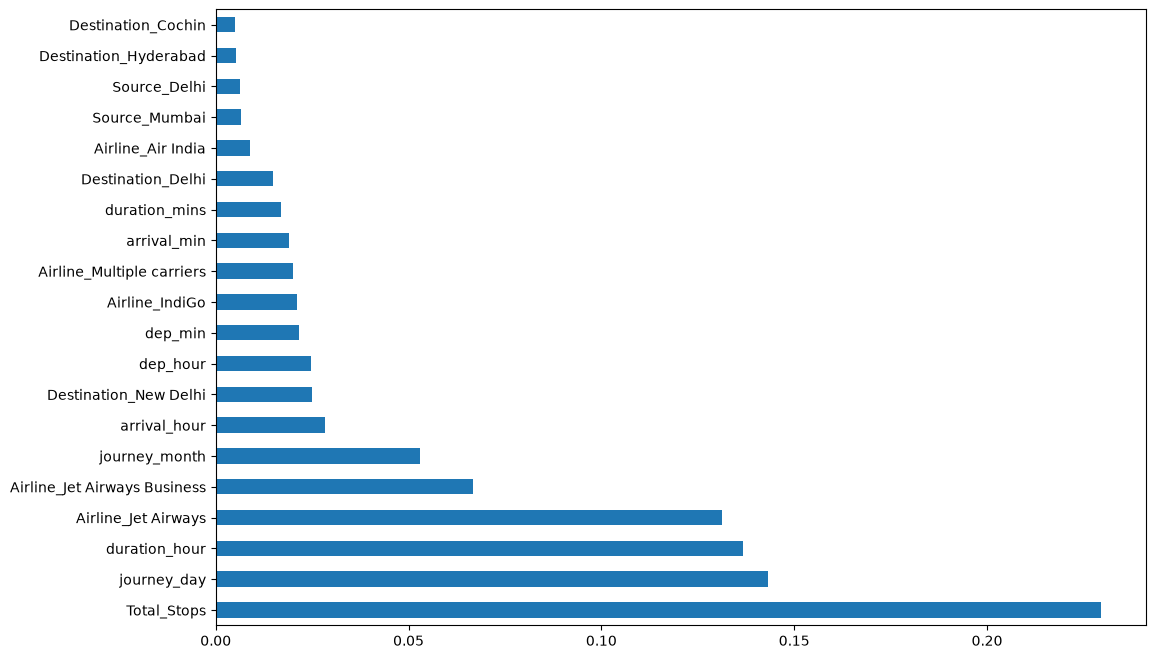

In [9]:
# Finding important feature using ExtraTreeRegressor

from sklearn.ensemble import ExtraTreesRegressor
selection=ExtraTreesRegressor()
selection.fit(X,y)

# lets plot the graph of feature importance for better visulization
plt.figure(figsize=(12,8))
feat_importances=pd.Series(selection.feature_importances_, index=X.columns)
feat_importances.nlargest(20).plot(kind='barh')
plt.show()

### Divid dataset into train and test

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2, random_state=42)

### Import Models

In [11]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model Before Tuning

In [12]:
# Dictionary of models to try
models = {
    'Linear Regression': LinearRegression(),
    'LogisticRegression':LogisticRegression(),
    'XGBoost': XGBRegressor(),
    'LightGBM': LGBMRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR()
}

results = []

for name, model in models.items():
    # Fit
    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training And Testing Score
    train_score=model.score(X_train,y_train)
    test_score=model.score(X_test,y_test)
    
    # Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train R2': round(train_r2, 4),
        'Test R2': round(test_r2, 4),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2)
    })
    
    # Print details for each model
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(f'Training Accuracy is : {train_score:.4f}')
    print(f'Test accuracy is : {test_score:.4f}')
    print(f"Training R2 Score : {train_r2:.4f}")
    print(f"Test R2 Score     : {test_r2:.4f}")
    print(f"MSE               : {mse:.2f}")
    print(f"RMSE              : {rmse:.2f}")
    print(f"MAE               : {mae:.2f}")

# Summary table sorted by test R2
results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False)
print("\n\nSummary (sorted by Test R2):")
print(results_df.to_string(index=False))


Model: Linear Regression
Training Accuracy is : 0.6241
Test accuracy is : 0.6196
Training R2 Score : 0.6241
Test R2 Score     : 0.6196
MSE               : 8202327.56
RMSE              : 2863.97
MAE               : 1972.94


c:\Users\A\Desktop\Flight Price Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: LogisticRegression
Training Accuracy is : 0.2411
Test accuracy is : 0.1965
Training R2 Score : 0.2546
Test R2 Score     : 0.3119
MSE               : 14837782.80
RMSE              : 3851.98
MAE               : 2398.99

Model: XGBoost
Training Accuracy is : 0.9371
Test accuracy is : 0.8460
Training R2 Score : 0.9371
Test R2 Score     : 0.8460
MSE               : 3321347.00
RMSE              : 1822.46
MAE               : 1126.70
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000412 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 178
[LightGBM] [Info] Number of data points in the train set: 8545, number of used features: 25
[LightGBM] [Info] Start training from score 9078.336688

Model: LightGBM
Training Accuracy is : 0.8733
Test accuracy is : 0.8258
Tr

### Hyper Parametor Tuning and Run with MLflow

In [15]:
import os
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
from sklearn.model_selection import RandomizedSearchCV

# ============================================================
# 1. MLflow local tracking setup
# ============================================================
os.environ.pop("MLFLOW_TRACKING_URI", None)  # clear any stale/conflicting URI

mlflow.set_tracking_uri("http://127.0.0.1:5000")
print("Tracking URI:", mlflow.get_tracking_uri())

experiment_name = "Flight_Fare_Prediction"
mlflow.set_experiment(experiment_name)


# ============================================================
# 2. Helper: log model with the correct MLflow flavor
#    (avoids the skops 'untrusted types' error for XGBoost/LightGBM)
# ============================================================
def log_model_by_type(model, artifact_path="model"):
    if isinstance(model, XGBRegressor):
        mlflow.xgboost.log_model(model, artifact_path)
    elif isinstance(model, LGBMRegressor):
        mlflow.lightgbm.log_model(model, artifact_path)
    else:
        mlflow.sklearn.log_model(model, artifact_path)


# ============================================================
# 3. Hyperparameter search spaces
#    (Linear Regression excluded — no meaningful hyperparameters to tune)
# ============================================================
param_grids = {
    'XGBoost': {
        'model': XGBRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [3, 4, 5, 6, 8],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0],
            'min_child_weight': [1, 3, 5]
        }
    },
    'LightGBM': {
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [-1, 5, 10],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'num_leaves': [15, 31, 63, 127],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0]
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'max_depth': [None, 5, 10, 15, 20, 30],
            'min_samples_split': [2, 5, 10, 20],
            'min_samples_leaf': [1, 2, 4, 8],
            'max_features': ['sqrt', 'log2', None]
        }
    },
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [None, 5, 10, 15, 20],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2']
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 4, 5, 6, 8],
            'subsample': [0.6, 0.8, 1.0],
            'min_samples_split': [2, 5, 10]
        }
    },
    'AdaBoost': {
        'model': AdaBoostRegressor(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],
            'learning_rate': [0.01, 0.05, 0.1, 0.5, 1.0]
        }
    },
    
}

Tracking URI: http://127.0.0.1:5000


In [16]:
best_models = {}
tuning_results = []


# ============================================================
# 4. Linear Regression — fit directly (no tuning needed)
# ============================================================
with mlflow.start_run(run_name='Linear Regression'):
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    best_models['Linear Regression'] = lr

    y_train_pred = lr.predict(X_train)
    y_test_pred = lr.predict(X_test)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    mse = mean_squared_error(y_test, y_test_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_test_pred)

    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mae", mae)
    log_model_by_type(lr)

    print(f"Linear Regression logged — Test R2: {test_r2:.4f}")

    tuning_results.append({
        'Model': 'Linear Regression', 'Best CV R2': np.nan,
        'Train R2': round(train_r2, 4), 'Test R2': round(test_r2, 4),
        'MSE': round(mse, 2), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2),
        'Best Params': {}
    })


# ============================================================
# 5. Remaining models — RandomizedSearchCV + MLflow logging
# ============================================================
for name, config in param_grids.items():
    with mlflow.start_run(run_name=name):
        search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            n_iter=20,
            cv=5,
            scoring='r2',
            n_jobs=-1,
            random_state=42
        )
        search.fit(X_train, y_train)

        best_model = search.best_estimator_
        best_models[name] = best_model

        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)

        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        mse = mean_squared_error(y_test, y_test_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_test_pred)

        mlflow.log_params(search.best_params_)
        mlflow.log_metric("best_cv_r2", search.best_score_)
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_r2", test_r2)
        mlflow.log_metric("mse", mse)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)

        log_model_by_type(best_model)

        print(f"{name} logged — Test R2: {test_r2:.4f} | Best Params: {search.best_params_}")

        tuning_results.append({
            'Model': name,
            'Best CV R2': round(search.best_score_, 4),
            'Train R2': round(train_r2, 4),
            'Test R2': round(test_r2, 4),
            'MSE': round(mse, 2),
            'RMSE': round(rmse, 2),
            'MAE': round(mae, 2),
            'Best Params': search.best_params_
        })


# ============================================================
# 6. Summary
# ============================================================
results_df = pd.DataFrame(tuning_results).sort_values(by='Test R2', ascending=False)
print("\n\nFinal Tuned Model Comparison:")
print(results_df[['Model', 'Best CV R2', 'Train R2', 'Test R2', 'MSE', 'RMSE', 'MAE']].to_string(index=False))

2026/08/15 22:20:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression logged — Test R2: 0.6196
🏃 View run Linear Regression at: http://127.0.0.1:5000/#/experiments/3/runs/851f1bc714034e68a907e5c5ddcbd150
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/08/15 22:21:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


XGBoost logged — Test R2: 0.8321 | Best Params: {'subsample': 1.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
🏃 View run XGBoost at: http://127.0.0.1:5000/#/experiments/3/runs/0a35a086b2a142af84f479c8737b03f8
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/08/15 22:22:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

Random Forest logged — Test R2: 0.8173 | Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}
🏃 View run Random Forest at: http://127.0.0.1:5000/#/experiments/3/runs/1f676cd3366846dfa9ed1079e2110df9
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


2026/08/15 22:28:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosting logged — Test R2: 0.8378 | Best Params: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 6, 'learning_rate': 0.05}
🏃 View run Gradient Boosting at: http://127.0.0.1:5000/#/experiments/3/runs/5ba3b2d8c021423887f7ab89028bfc7d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


c:\Users\A\Desktop\Flight Price Prediction\venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 15 is smaller than n_iter=20. Running 15 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
2026/08/15 22:30:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


AdaBoost logged — Test R2: 0.5232 | Best Params: {'n_estimators': 50, 'learning_rate': 0.05}
🏃 View run AdaBoost at: http://127.0.0.1:5000/#/experiments/3/runs/b537dda84c4b44e3919b98a4359c363a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Final Tuned Model Comparison:
            Model  Best CV R2  Train R2  Test R2         MSE    RMSE     MAE
Gradient Boosting      0.8212    0.9018   0.8378  3498229.32 1870.36 1220.08
          XGBoost      0.8309    0.9272   0.8321  3619514.50 1902.50 1149.19
         LightGBM      0.8155    0.8989   0.8264  3742323.35 1934.51 1176.67
    Random Forest      0.7940    0.8675   0.8173  3940168.61 1984.99 1304.41
    Decision Tree      0.7843    0.8833   0.7794  4756273.07 2180.89 1233.63
Linear Regression         NaN    0.6241   0.6196  8202327.56 2863.97 1972.94
         AdaBoost      0.5444    0.5546   0.5232 10280201.86 3206.28 2249.71


### Sanity-check the model isn't overfitting or leaking

In [17]:
# Compare train vs test R2 — big gap = overfitting
print(f"Train R2: {train_r2:.4f}")
print(f"Test R2: {test_r2:.4f}")

# Cross-validation to confirm stability (not just a lucky split)
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_models['XGBoost'], X_train, y_train, cv=5, scoring='r2')
print(f"CV R2 scores: {cv_scores}")
print(f"CV R2 mean ± std: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Train R2: 0.5546
Test R2: 0.5232
CV R2 scores: [0.84978968 0.86485708 0.79988122 0.80860835 0.83137161]
CV R2 mean ± std: 0.8309 ± 0.0244


### Residual analysis

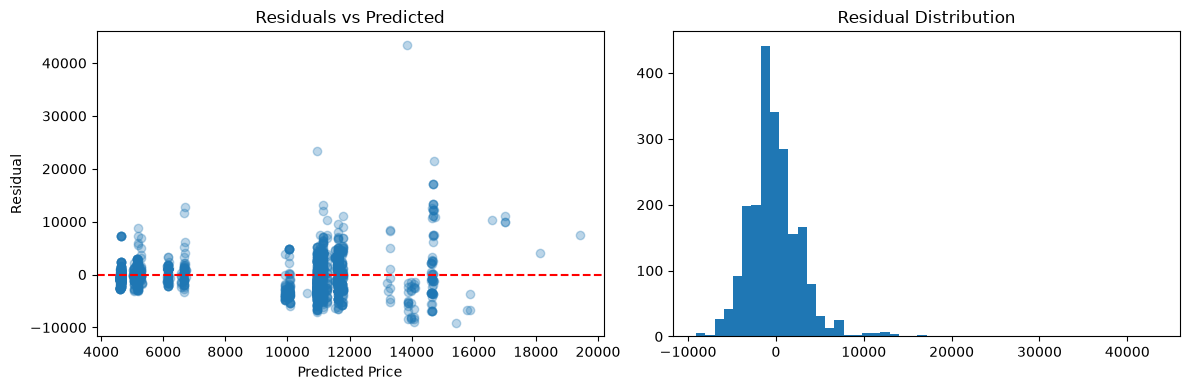

In [18]:
residuals = y_test - y_test_pred

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_test_pred, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted')

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=50)
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

### Explain it with SHAP

c:\Users\A\Desktop\Flight Price Prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


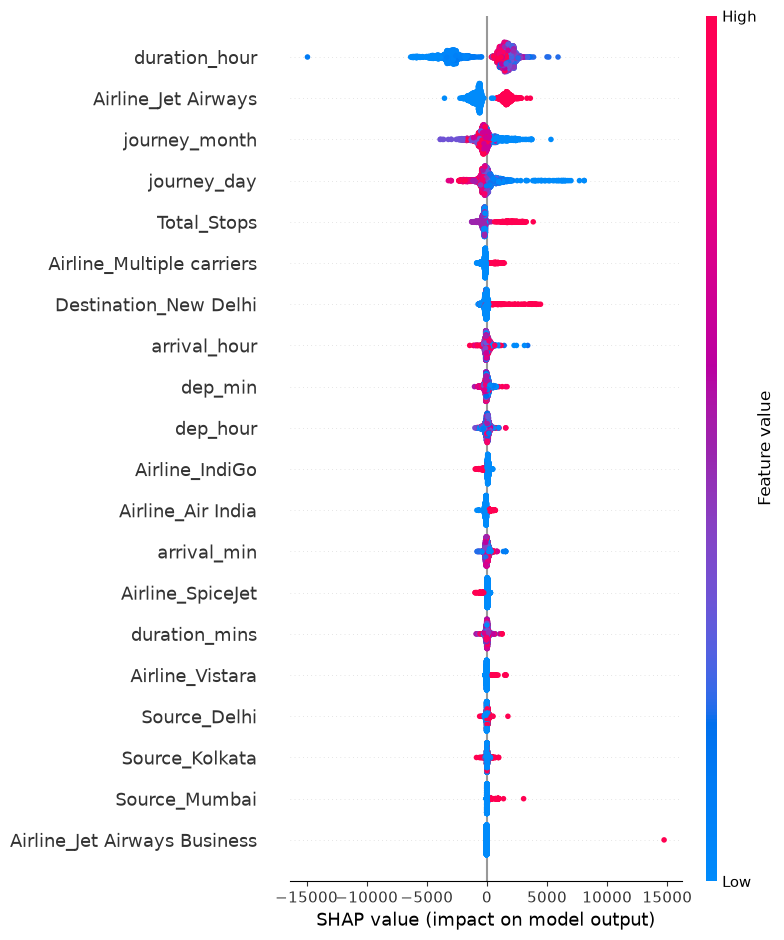

In [20]:
import shap
explainer = shap.TreeExplainer(best_models['XGBoost'])
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

### Register the model formally in MLflow

In [21]:
run_id = "0a35a086b2a142af84f479c8737b03f8"  
model_uri = f"runs:/{run_id}/model"

mlflow.register_model(model_uri, "flight-price-xgboost")

Successfully registered model 'flight-price-xgboost'.
2026/08/15 22:42:53 WARNING mlflow.tracking._model_registry.fluent: Run with id 0a35a086b2a142af84f479c8737b03f8 has no artifacts at artifact path 'model', registering model based on models:/m-2ca35971d7f6451a80d8f0847a6e3e49 instead
2026/08/15 22:42:54 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: flight-price-xgboost, version 1
Created version '1' of model 'flight-price-xgboost'.


<ModelVersion: aliases=[], creation_timestamp=1786858974030, current_stage='None', deployment_job_state=<ModelVersionDeploymentJobState: current_task_name='', job_id='', job_state='DEPLOYMENT_JOB_CONNECTION_STATE_UNSPECIFIED', run_id='', run_state='DEPLOYMENT_JOB_RUN_STATE_UNSPECIFIED'>, description='', last_updated_timestamp=1786858974030, metrics=None, model_id=None, name='flight-price-xgboost', params=None, run_id='0a35a086b2a142af84f479c8737b03f8', run_link='', source='models:/m-2ca35971d7f6451a80d8f0847a6e3e49', status='READY', status_message=None, tags={}, user_id='', version='1', workspace='default'>

### Save preprocessing artifacts alongside

In [ ]:
import joblib
joblib.dump(best_models['XGBoost'], 'xgb_flight_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')  # whatever you used for categorical cols
joblib.dump(list(X_train.columns), 'feature_columns.pkl')  # to enforce column order at inference